### Imports

In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image
import time
import pandas as pd
import pyopencl as cl
import matplotlib.pyplot as plt

## pd.set_option("display.max_rows", None)

### Config

In [390]:
image_paths = [
    Path("images_input/1.nature_small.jpeg"),
    Path("images_input/2.nature_medium.jpeg"),
    Path("images_input/3.nature_large.jpeg"),
    Path("images_input/4.nature_mega.jpeg"),
]

alpha_cpu = 1.3
beta_cpu = 20

alpha_pyopencl = np.float32(1.3)
beta_pyopencl = np.float32(20)

runs = 100
warmup_runs = 5

### Baseline

In [391]:
def process_cpu(rgb_matrix):
    red = rgb_matrix[:, :, 0]
    green = rgb_matrix[:, :, 1]
    blue = rgb_matrix[:, :, 2]

    gray_matrix = 0.21 * red + 0.72 * green + 0.07 * blue
    gray_matrix = gray_matrix.astype(np.uint8)

    gray_matrix_2 = alpha_cpu * gray_matrix + beta_cpu
    gray_matrix_2 = np.clip(gray_matrix_2, 0, 255)
    gray_matrix_2 = gray_matrix_2.astype(np.uint8)

    histogram = np.bincount(gray_matrix_2.flatten(), minlength=256)

    return gray_matrix_2, histogram

### PyOpenCL Config

In [392]:
context = cl.create_some_context()
queue = cl.CommandQueue(context)

mf = cl.mem_flags

program = cl.Program(context, """
__kernel void rgb_to_grayscale_brightness_contrast(
    __global const uchar *rgb,
    __global uchar *gray_out,
    const float alpha,
    const float beta
)
{
    int pixel_id = get_global_id(0);
    int rgb_id = pixel_id * 3;

    uchar red = rgb[rgb_id];
    uchar green = rgb[rgb_id + 1];
    uchar blue = rgb[rgb_id + 2];

    uchar gray_value = (uchar)(0.21f * red + 0.72f * green + 0.07f * blue);
    float value = alpha * gray_value + beta;

    if (value < 0.0f) {
        value = 0.0f;
    }

    if (value > 255.0f) {
        value = 255.0f;
    }

    gray_out[pixel_id] = (uchar)(value);
}
""").build()

### PyOpenCL Func

In [393]:
def process_pyopencl(rgb_matrix):
    height, width, channels = rgb_matrix.shape
    pixel_count = height * width

    rgb_flat = rgb_matrix.flatten()
    gray_matrix_flat = np.empty(pixel_count, dtype=np.uint8)

    rgb_input_buffer = cl.Buffer(context, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=rgb_flat)
    gray_output_buffer = cl.Buffer(context, mf.WRITE_ONLY, gray_matrix_flat.nbytes)

    program.rgb_to_grayscale_brightness_contrast(
        queue,
        (pixel_count,),
        None,
        rgb_input_buffer,
        gray_output_buffer,
        alpha_pyopencl,
        beta_pyopencl
    )

    cl.enqueue_copy(queue, gray_matrix_flat, gray_output_buffer)
    queue.finish()

    gray_matrix_2 = gray_matrix_flat.reshape((height, width))
    histogram = np.bincount(gray_matrix_2.flatten(), minlength=256)

    return gray_matrix_2, histogram

### Benchmark Baseline

In [394]:
cpu_results = []

for image_path in image_paths:
    image = Image.open(image_path)
    rgb_matrix = np.array(image, dtype=np.uint8)

    height, width, channels = rgb_matrix.shape
    pixel_count = height * width

    for _ in range(warmup_runs): # Warm-up
       process_cpu(rgb_matrix)  

    for run in range(1, runs + 1):
        start = time.perf_counter()

        cpu_image, cpu_histogram = process_cpu(rgb_matrix)

        end = time.perf_counter()

        cpu_results.append({
            "image": image_path.name,
            "width": width,
            "height": height,
            "pixel_count": pixel_count,
            "run": run,
            "cpu_time_s": end - start
        })

cpu_raw_df = pd.DataFrame(cpu_results)
cpu_raw_df

,image,width,height,pixel_count,run,cpu_time_s
0,1.nature_small.jpeg,640,415,265600,1,0.003137
1,1.nature_small.jpeg,640,415,265600,2,0.002336
2,1.nature_small.jpeg,640,415,265600,3,0.001776
3,1.nature_small.jpeg,640,415,265600,4,0.001924
4,1.nature_small.jpeg,640,415,265600,5,0.002105
5,1.nature_small.jpeg,640,415,265600,6,0.002602
6,1.nature_small.jpeg,640,415,265600,7,0.001986
7,1.nature_small.jpeg,640,415,265600,8,0.002361
8,1.nature_small.jpeg,640,415,265600,9,0.001832
9,1.nature_small.jpeg,640,415,265600,10,0.001666


### Benchmark PyOpenCl

In [395]:
pyopencl_results = []

for image_path in image_paths:
    image = Image.open(image_path)
    rgb_matrix = np.array(image, dtype=np.uint8)

    height, width, channels = rgb_matrix.shape
    pixel_count = height * width

    for _ in range(warmup_runs): # Warm-up
        process_pyopencl(rgb_matrix)

    for run in range(1, runs + 1):
        start = time.perf_counter()

        pyopencl_image, pyopencl_histogram = process_pyopencl(rgb_matrix)

        end = time.perf_counter()

        pyopencl_results.append({
            "image": image_path.name,
            "width": width,
            "height": height,
            "pixel_count": pixel_count,
            "run": run,
            "pyopencl_time_s": end - start
        })

pyopencl_raw_df = pd.DataFrame(pyopencl_results)
pyopencl_raw_df

C:\Users\maxim\AppData\Local\Temp\ipykernel_52504\4061707263.py:11: RepeatedKernelRetrieval: Kernel 'rgb_to_grayscale_brightness_contrast' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  program.rgb_to_grayscale_brightness_contrast(


,image,width,height,pixel_count,run,pyopencl_time_s
0,1.nature_small.jpeg,640,415,265600,1,0.000963
1,1.nature_small.jpeg,640,415,265600,2,0.001168
2,1.nature_small.jpeg,640,415,265600,3,0.000849
3,1.nature_small.jpeg,640,415,265600,4,0.000736
4,1.nature_small.jpeg,640,415,265600,5,0.000750
5,1.nature_small.jpeg,640,415,265600,6,0.000736
6,1.nature_small.jpeg,640,415,265600,7,0.000736
7,1.nature_small.jpeg,640,415,265600,8,0.000748
8,1.nature_small.jpeg,640,415,265600,9,0.000733
9,1.nature_small.jpeg,640,415,265600,10,0.000831


### Tabelle Median und Speedup

In [396]:
cpu_median_df = (
    cpu_raw_df
    .groupby(["image", "width", "height", "pixel_count"], as_index=False)
    ["cpu_time_s"]
    .median()
)

pyopencl_median_df = (
    pyopencl_raw_df
    .groupby(["image", "width", "height", "pixel_count"], as_index=False)
    ["pyopencl_time_s"]
    .median()
)

summary_df = cpu_median_df.merge(
    pyopencl_median_df,
    on=["image", "width", "height", "pixel_count"]
)

summary_df["speedup"] = summary_df["cpu_time_s"] / summary_df["pyopencl_time_s"]
summary_df = summary_df.sort_values("pixel_count")
summary_df

,image,width,height,pixel_count,cpu_time_s,pyopencl_time_s,speedup
0,1.nature_small.jpeg,640,415,265600,0.001719,0.000930,1.847721
1,2.nature_medium.jpeg,1024,663,678912,0.004899,0.003035,1.614145
2,3.nature_large.jpeg,1280,829,1061120,0.032464,0.006912,4.696922
3,4.nature_mega.jpeg,2048,1327,2717696,0.081066,0.016662,4.865241


### Plot 1: Laufzeitvergleich

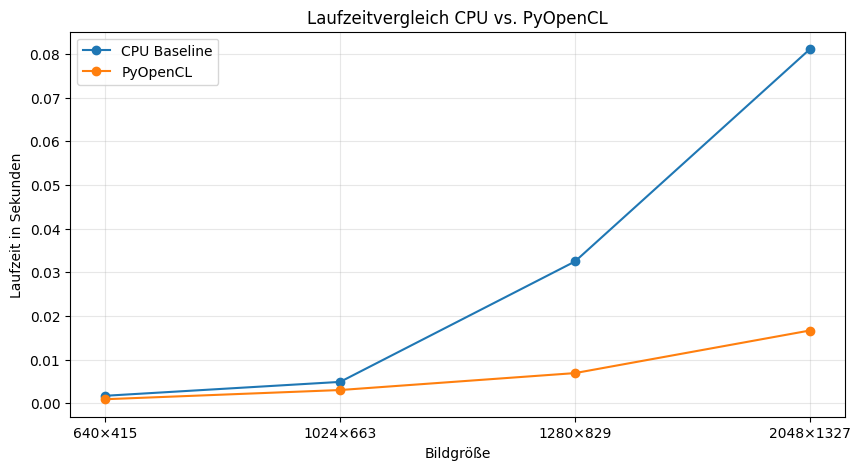

In [397]:
x_labels = summary_df["width"].astype(str) + "×" + summary_df["height"].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(x_labels, summary_df["cpu_time_s"], marker="o", label="CPU Baseline")
plt.plot(x_labels, summary_df["pyopencl_time_s"], marker="o", label="PyOpenCL")

plt.xlabel("Bildgröße")
plt.ylabel("Laufzeit in Sekunden")
plt.title("Laufzeitvergleich CPU vs. PyOpenCL")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Plot 2: Speedup

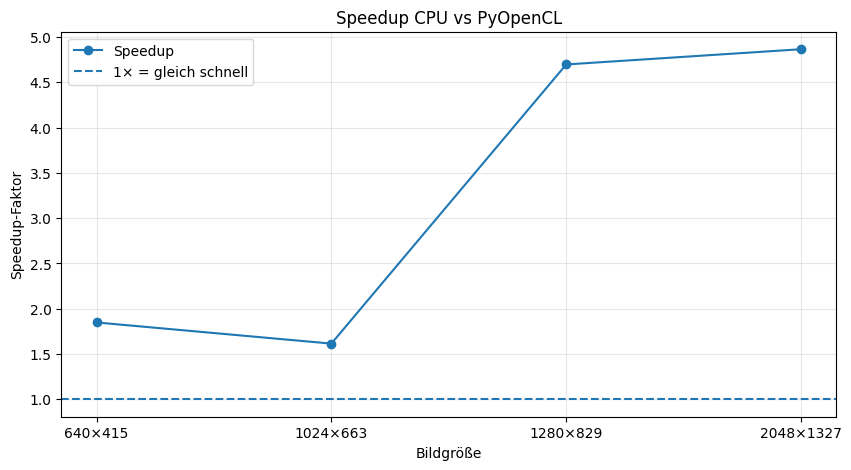

In [398]:
plt.figure(figsize=(10, 5))
plt.plot(x_labels, summary_df["speedup"], marker="o", label="Speedup")
plt.axhline(1.0, linestyle="--", label="1× = gleich schnell")
plt.xlabel("Bildgröße")
plt.ylabel("Speedup-Faktor")
plt.title("Speedup CPU vs PyOpenCL")
plt.grid(alpha=0.3)
plt.legend()
plt.show()